# Problem set 2

In class and in Forsyth and Ponce, chapter 7 we discussed window-based approaches to estimating dense stereo correspondence. In this problem set you will implement such approaches and evaluate it on some standard stereo pairs.

Anywhere you see `...` you need to fill in with your own choices.

In [1]:
import os
import time 
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.set_cmap('gray')

<Figure size 640x480 with 0 Axes>

In [2]:
def imsave(image: np.ndarray, path):
    norm_image = (((image - image.min()) / (image.max() - image.min())) * 255).astype(np.uint8)
    cv2.imwrite(path, norm_image)

# Part 1

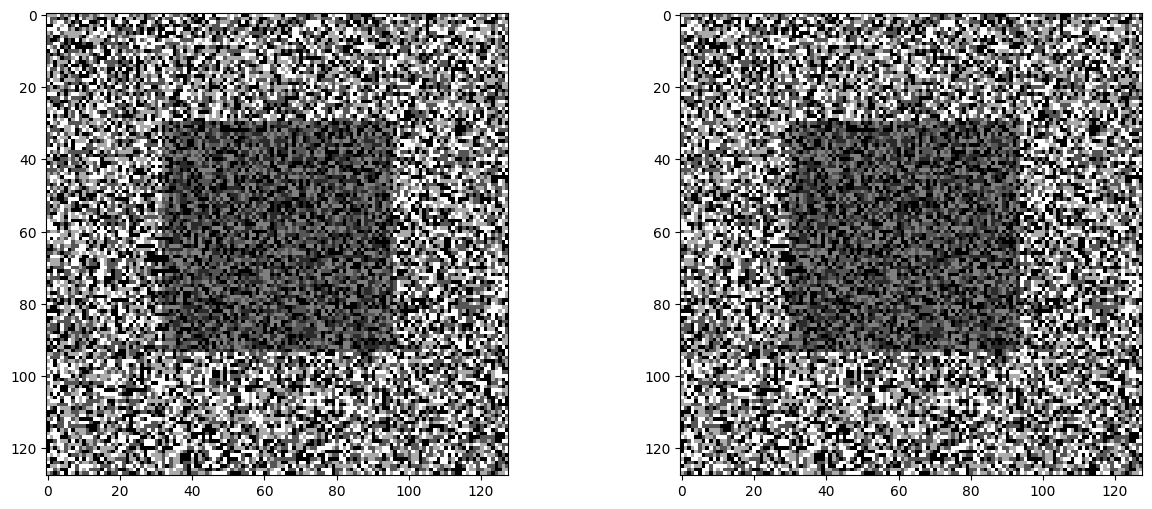

In [3]:
L = cv2.imread(os.path.join('input', 'pair0-L.png'), 0) / 255
R = cv2.imread(os.path.join('input', 'pair0-R.png'), 0) / 255

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(L)
plt.subplot(122)
plt.imshow(R)
plt.show()

## Part A

Implement the SSD match algorithm as function disparity_ssd(L, R) that returns a disparity image D(y,x) such that L(y,x) = R(y,x+D(y,x)) when matching from left (L) to right (R).

You will implement this function in numerous versions, pixel-wise, vectorized and with shared computations.

Consider what parameters you'd like your function to have, consider runtime and assumptions you can make of the output.

### Pixel wise

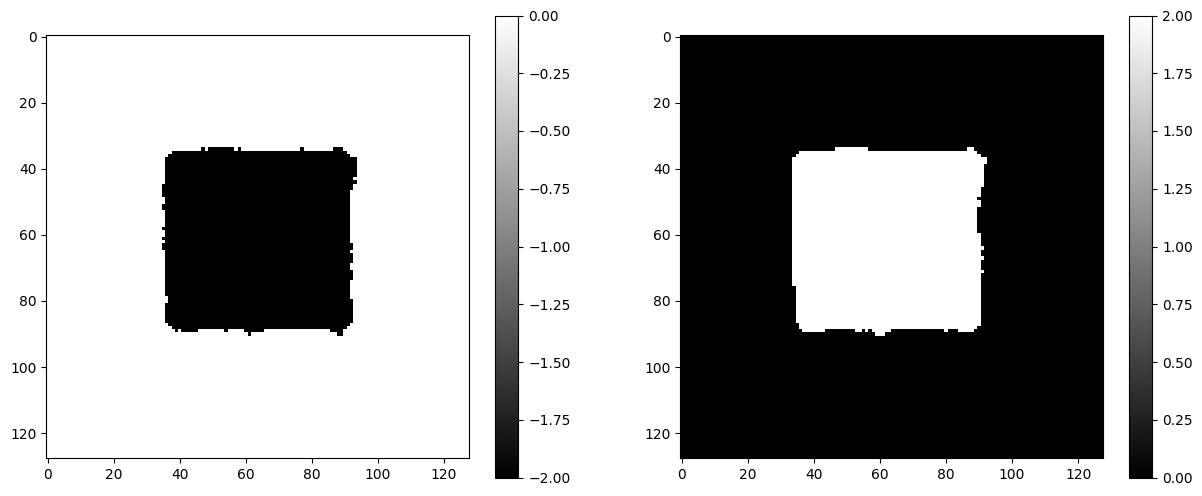

In [4]:
def disparity_ssd_pixel_wise(L: np.ndarray, R: np.ndarray, box_size: int):
    """Compute disparity map D(y, x) such that: L(y, x) = R(y, x + D(y, x))

    This function computes disparity separately for each pixel

    Params:
    L: Grayscale left image
    R: Grayscale right image, same size as L

    Returns: Disparity map, same size as L, R
    """
    D = np.zeros(L.shape)
    L_pad = np.pad(L, box_size // 2, mode='constant', constant_values=0)
    R_pad = np.pad(R, box_size // 2, mode='constant', constant_values=0)
    L_patches = np.lib.stride_tricks.sliding_window_view(L_pad, (box_size, box_size))
    R_patches = np.lib.stride_tricks.sliding_window_view(R_pad, (box_size, box_size))
    for y in range(L.shape[0]):
        for x in range(L.shape[1]):
            L_patch = L_patches[y, x]
            best_match = 0
            best_ssd = np.inf
            for d in range(-x, R.shape[1] - x):
                if 0 <= x + d < R.shape[1]:
                    R_patch = R_patches[y, x + d]
                    ssd = np.sum((L_patch - R_patch) ** 2)
                    if ssd < best_ssd:
                        best_ssd = ssd
                        best_match = d
            D[y, x] = best_match
    return D

b_size = 15

D_L = disparity_ssd_pixel_wise(L, R, b_size)
D_R = disparity_ssd_pixel_wise(R, L, b_size)

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R)
plt.colorbar()
plt.show()

Computing disparity map: 100%|██████████| 128/128 [00:00<00:00, 169.35it/s]


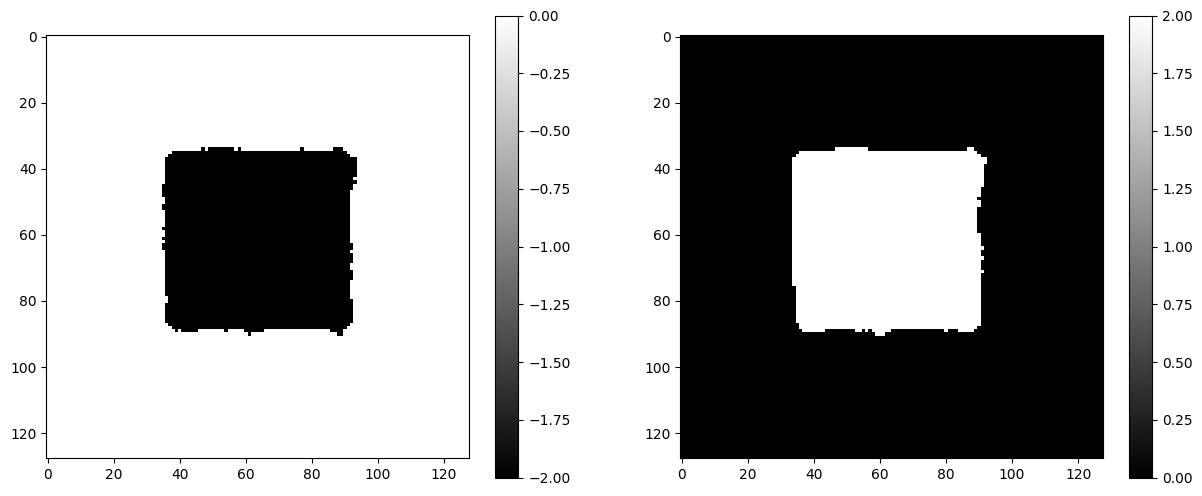

In [5]:
def disparity_ssd_pixelwise_with_max_disparity(L: np.ndarray, R: np.ndarray, box_size: int, max_disparity: int = 100):
    """Compute disparity map D(y, x) such that: L(y, x) = R(y, x + D(y, x))

    This function computes disparity separately for each pixel

    Params:
    L: Grayscale left image
    R: Grayscale right image, same size as L

    Returns: Disparity map, same size as L, R
    """
    D = np.zeros(L.shape)
    L_pad = np.pad(L, box_size // 2, mode='edge')
    R_pad = np.pad(R, box_size // 2, mode='edge')
    L_patches = np.lib.stride_tricks.sliding_window_view(
        L_pad, (box_size, box_size))
    R_patches = np.lib.stride_tricks.sliding_window_view(
        R_pad, (box_size, box_size))
    for y in tqdm(range(L.shape[0]), desc='Computing disparity map'):
        for x in range(L.shape[1]):
            L_patch = L_patches[y, x]
            best_match = 0
            R_row_patches = R_patches[y, max(
                0, x - max_disparity):min(R.shape[1], x + max_disparity + 1)]
            ssd_values = np.sum((R_row_patches - L_patch) ** 2, axis=(1, 2))
            best_match = np.argmin(ssd_values)
            disparity = best_match + max(0, x - max_disparity) - x
            D[y, x] = disparity
    return D


D_L = disparity_ssd_pixelwise_with_max_disparity(L, R, b_size, 100)
D_R = disparity_ssd_pixelwise_with_max_disparity(R, L, b_size, 100)
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R)
plt.colorbar()
plt.show()

This looks pretty much perfect.

### Vectorized

How would you like to vectorize the functions? Try out a few variations.

Consider the parameters of your function as well as memory constraints.

You may ask your mentor for help.

Computing disparity map: 100%|██████████| 128/128 [00:00<00:00, 200.79it/s]


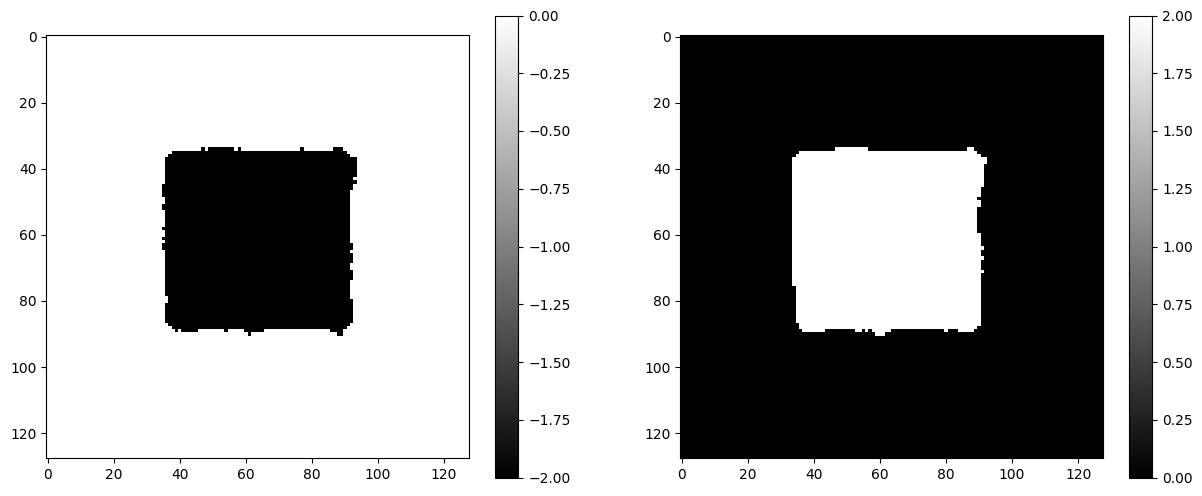

In [6]:
def disparity_ssd_semi_vectorized(L: np.ndarray, R: np.ndarray, box_size: int):
    """Compute disparity map D(y, x) such that: L(y, x) = R(y, x + D(y, x))

    This function computes disparity ...

    Params:
    L: Grayscale left image
    R: Grayscale right image, same size as L

    Returns: Disparity map, same size as L, R
    """
    D = np.zeros(L.shape)
    rows, cols = L.shape
    L_pad = np.pad(L, box_size // 2, mode='edge')
    R_pad = np.pad(R, box_size // 2, mode='edge')
    L_patches = np.lib.stride_tricks.sliding_window_view(
        L_pad, (box_size, box_size)).reshape((rows, cols, box_size * box_size))
    R_patches = np.lib.stride_tricks.sliding_window_view(
        R_pad, (box_size, box_size)).reshape((rows, cols, box_size * box_size))
    for y in tqdm(range(L.shape[0]), desc='Computing disparity map'):
        L_row_patches = L_patches[y, :, :]
        R_row_patches = R_patches[y, :, :]
        ssd_values = np.sum((R_row_patches[:, np.newaxis, :] - L_row_patches[np.newaxis, :, :]) ** 2, axis=2)
        best_matches = np.argmin(ssd_values, axis=0)
        D[y, :] = best_matches - np.arange(cols)
    return D


box_size = 15
D_L = disparity_ssd_semi_vectorized(L, R, box_size)
D_R = disparity_ssd_semi_vectorized(R, L, box_size)

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R)
plt.colorbar()
plt.show()

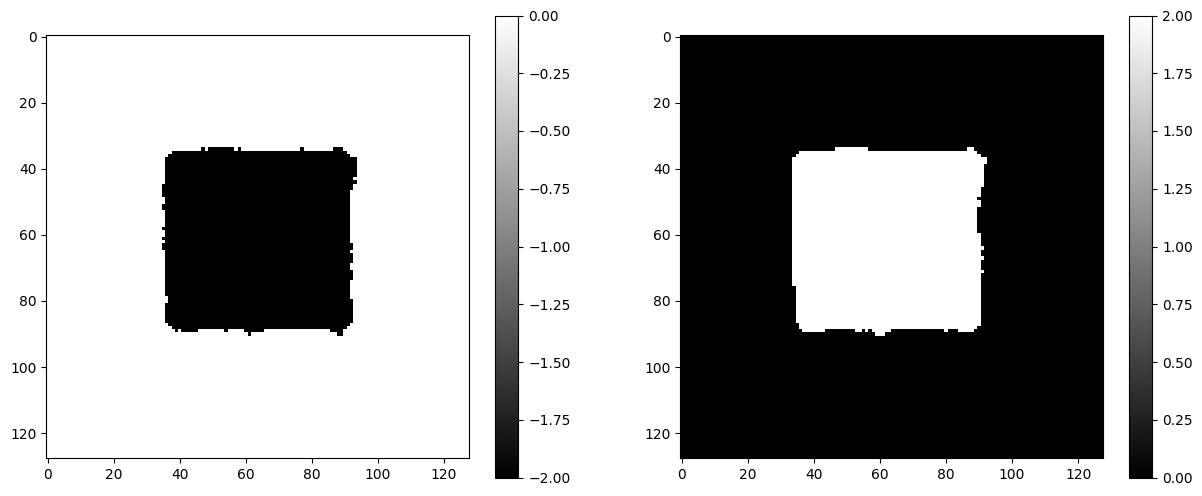

In [7]:
def disparity_ssd_vectorized(L: np.ndarray, R: np.ndarray, box_size: int):
    """Compute disparity map D(y, x) such that: L(y, x) = R(y, x + D(y, x))

    This function computes disparity ...

    Params:
    L: Grayscale left image
    R: Grayscale right image, same size as L

    Returns: Disparity map, same size as L, R
    """
    D = np.zeros(L.shape)
    rows, cols = L.shape
    L_pad = np.pad(L, box_size // 2, mode='edge')
    R_pad = np.pad(R, box_size // 2, mode='edge')
    L_patches = np.lib.stride_tricks.sliding_window_view(
        L_pad, (box_size, box_size)).reshape((rows, cols, box_size * box_size))
    R_patches = np.lib.stride_tricks.sliding_window_view(
        R_pad, (box_size, box_size)).reshape((rows, cols, box_size * box_size))
    ssd_values = np.sum((R_patches[:, np.newaxis, :, :] - L_patches[:, :, np.newaxis, :]) ** 2, axis=3)
    best_matches = np.argmin(ssd_values, axis=2)
    D = best_matches - np.arange(cols)[np.newaxis, :]
    return D

box_size = 15
D_L = disparity_ssd_vectorized(L, R, box_size)
D_R = disparity_ssd_vectorized(R, L, box_size)
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R)
plt.colorbar()
plt.show()

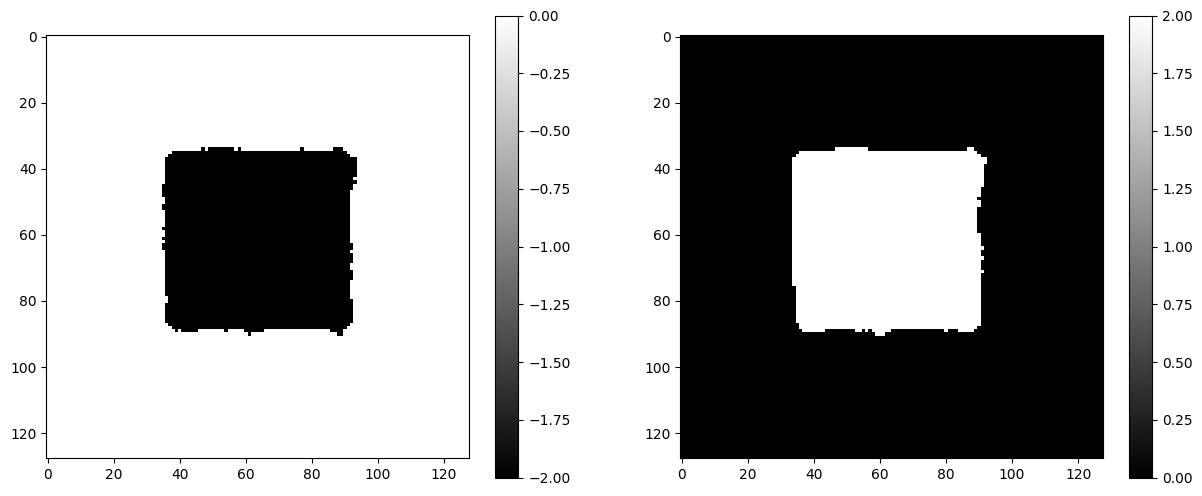

In [8]:
def disparity_ssd_vectorized_with_max_disparity(L: np.ndarray, R: np.ndarray, box_size: int, max_disparity: int = 20):
    """Compute disparity map D(y, x) such that: L(y, x) = R(y, x + D(y, x))

    This function computes disparity ...

    Params:
    L: Grayscale left image
    R: Grayscale right image, same size as L

    Returns: Disparity map, same size as L, R
    """
    disparity_map = np.zeros(L.shape)
    rows, cols = L.shape
    L_pad = np.pad(L, box_size // 2, mode='edge')
    R_pad = np.pad(R, box_size // 2, mode='edge')
    L_patches = np.lib.stride_tricks.sliding_window_view(
        L_pad, (box_size, box_size)).reshape((rows, cols, box_size * box_size))
    R_patches = np.lib.stride_tricks.sliding_window_view(
        R_pad, (box_size, box_size)).reshape((rows, cols, box_size * box_size))
    disparity_range = np.arange(-max_disparity, max_disparity + 1)
    shifted_cols = np.arange(cols) + disparity_range[:, np.newaxis]
    shifted_cols = np.clip(shifted_cols, 0, cols - 1)
    shifted_R_patches = R_patches[:, shifted_cols, :]
    ssd_values = np.sum(
        (shifted_R_patches[:, :, :, :] - L_patches[:, np.newaxis, :, :]) ** 2, axis=3)
    best_disparities = np.argmin(ssd_values, axis=1)
    disparity_map = disparity_range[best_disparities]
    disparity_map = np.clip(disparity_map, -max_disparity, max_disparity)
    disparity_map[:, 0] = disparity_map[:, 1]
    return disparity_map


box_size = 15
D_L = disparity_ssd_vectorized_with_max_disparity(L, R, box_size)
D_R = disparity_ssd_vectorized_with_max_disparity(R, L, box_size)
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R)
plt.colorbar()
plt.show()

# Part 2 A

Again apply your SSD match function, and create a disparity image D(y,x) such that L(y,x) = R(y,x+D(y,x)) when matching from left to right. Also match from right to left.

Try out the different versions you implemented and compare their runtimes and results. The results should all be the same.

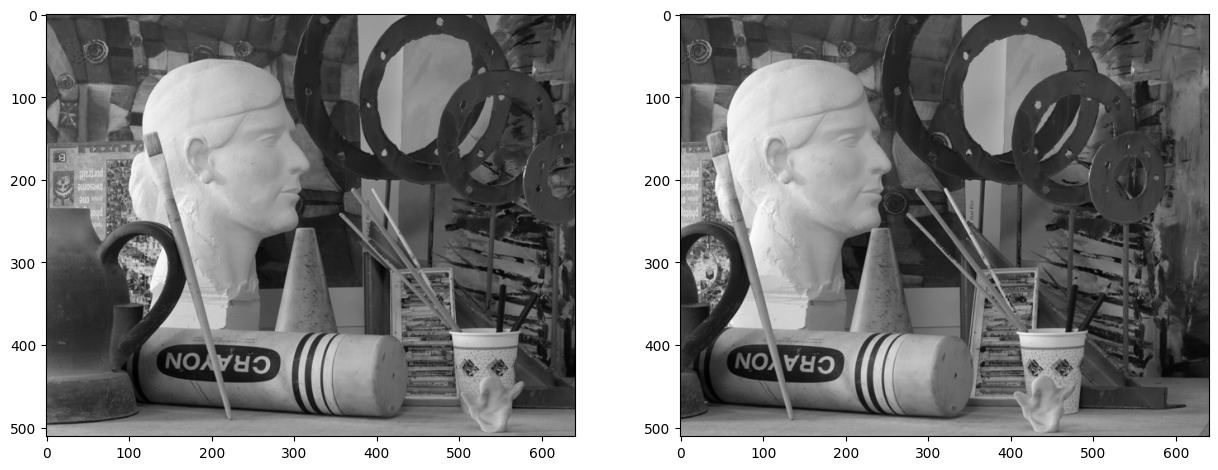

(511, 640)


In [15]:
L = cv2.imread(os.path.join('input', 'pair1-L.png'), 0) / 255
R = cv2.imread(os.path.join('input', 'pair1-R.png'), 0) / 255

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(L)
plt.subplot(122)
plt.imshow(R)
plt.show()
print(L.shape)

Computing disparity map: 100%|██████████| 511/511 [00:18<00:00, 27.77it/s]


Total runtime for function disparity_ssd_pixelwise_with_max_disparity is 36.85s


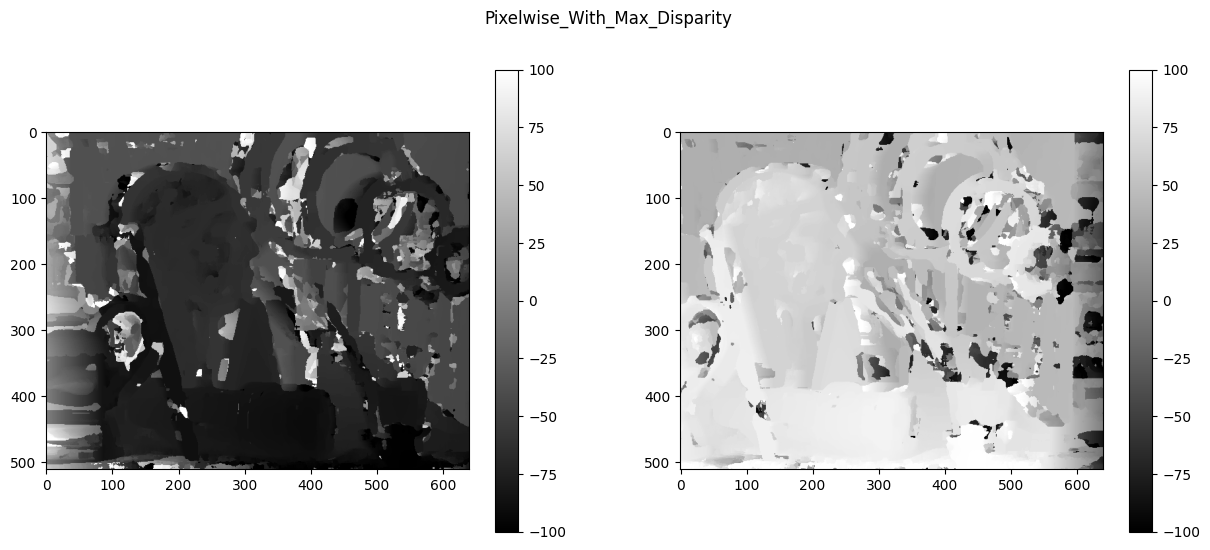

Computing disparity map: 100%|██████████| 511/511 [01:08<00:00,  7.50it/s]


Total runtime for function disparity_ssd_semi_vectorized is 135.91s


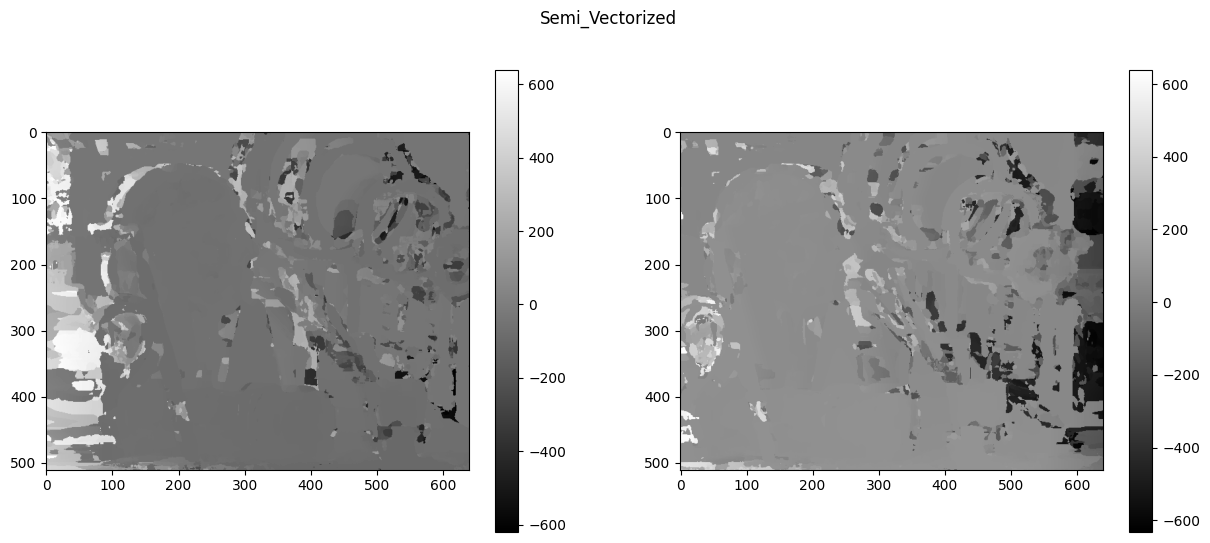

In [16]:
for disparity_func in [
    # disparity_ssd_vectorized_with_max_disparity,
    disparity_ssd_pixelwise_with_max_disparity,
    disparity_ssd_semi_vectorized
]:
    box_size = 15
    start = time.time()
    D_L = disparity_func(L, R, box_size)
    D_R = disparity_func(R, L, box_size)
    print('Total runtime for function {} is {:.2f}s'.format(disparity_func.__name__, time.time() - start))

    plt.figure(figsize=(15, 6))
    plt.suptitle(disparity_func.__name__.replace('disparity_ssd_', '').title())
    plt.subplot(121)
    plt.imshow(D_L)
    plt.colorbar()
    plt.subplot(122)
    plt.imshow(D_R)
    plt.colorbar()
    plt.show()

Surprisingly, pixel wise is much faster than columns wise. 

Unsurprisingly, the shared version is the fastest and produces almost identical results, so we'll use it from now on.

# Part 2 b

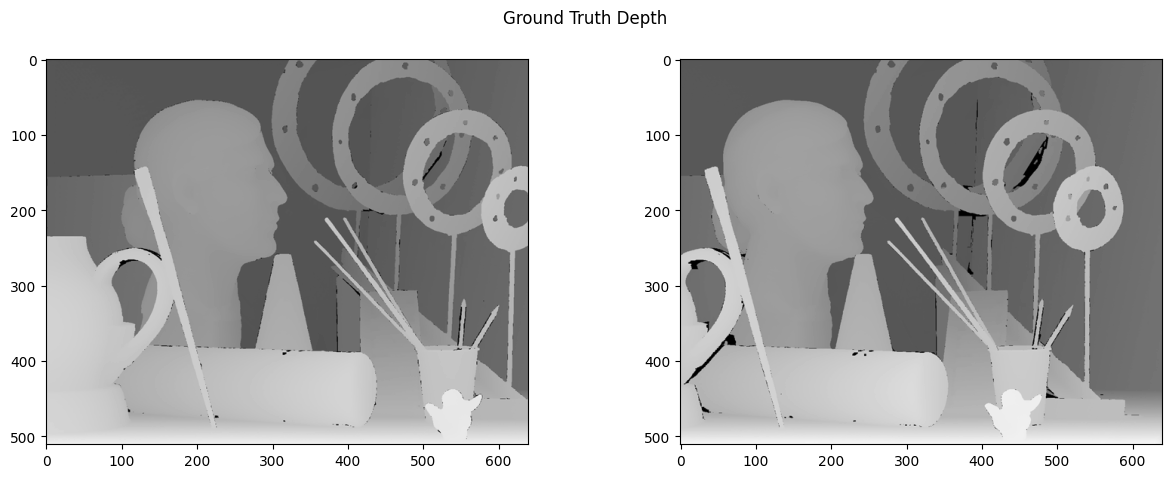

In [17]:
gt_D_L = cv2.imread(os.path.join('input', 'pair1-D_L.png'), 0) / 255
gt_D_R = cv2.imread(os.path.join('input', 'pair1-D_R.png'), 0) / 255

plt.figure(figsize=(15, 5))
plt.suptitle('Ground Truth Depth')
plt.subplot(121)
plt.imshow(gt_D_L)
plt.subplot(122)
plt.imshow(gt_D_R)
plt.show()

This is obviously much clearer than the depth our function gets, but a lot of the underlying structure is seen in both pictures.

# Part 3 a

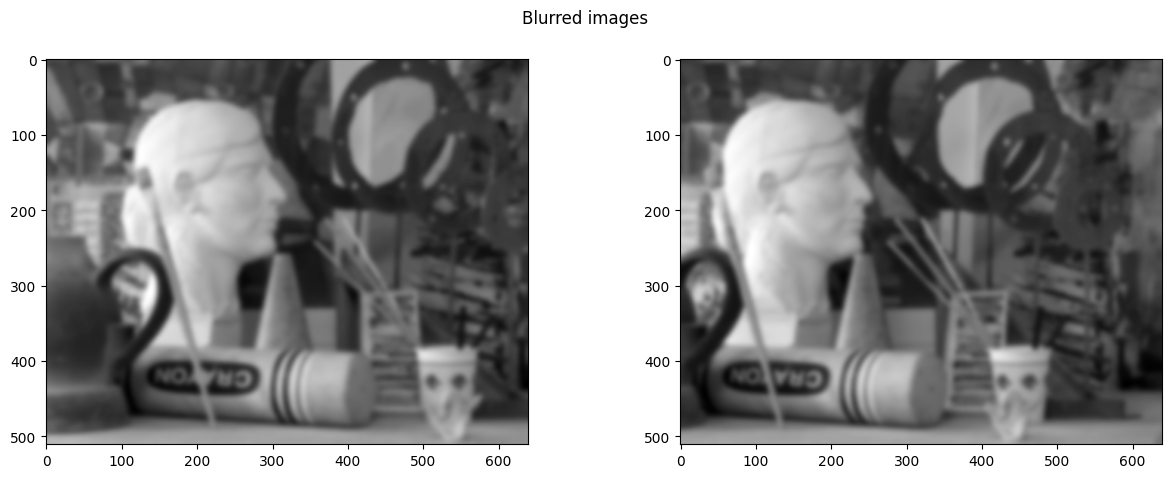

In [18]:
L_blur = cv2.GaussianBlur(L, (21, 21), 0)
R_blur = cv2.GaussianBlur(R, (21, 21), 0)

plt.figure(figsize=(15, 5))
plt.suptitle('Blurred images')
plt.subplot(121)
plt.imshow(L_blur)
plt.subplot(122)
plt.imshow(R_blur)
plt.show()

Computing disparity map: 100%|██████████| 511/511 [00:18<00:00, 27.68it/s]


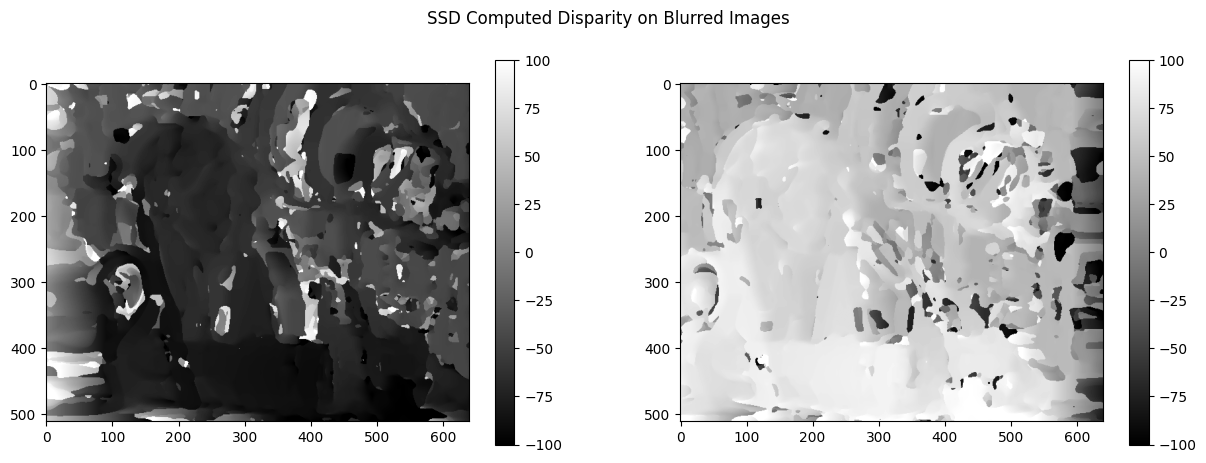

In [19]:
D_L_blur = disparity_ssd_pixelwise_with_max_disparity(L_blur, R_blur, box_size=15)
D_R_blur = disparity_ssd_pixelwise_with_max_disparity(R_blur, L_blur, box_size=15)

plt.figure(figsize=(15, 5))
plt.suptitle('SSD Computed Disparity on Blurred Images')
plt.subplot(121)
plt.imshow(D_L_blur)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R_blur)
plt.colorbar()
plt.show()

How does this look?

# Part 3 b

Computing disparity map: 100%|██████████| 511/511 [00:18<00:00, 27.85it/s]


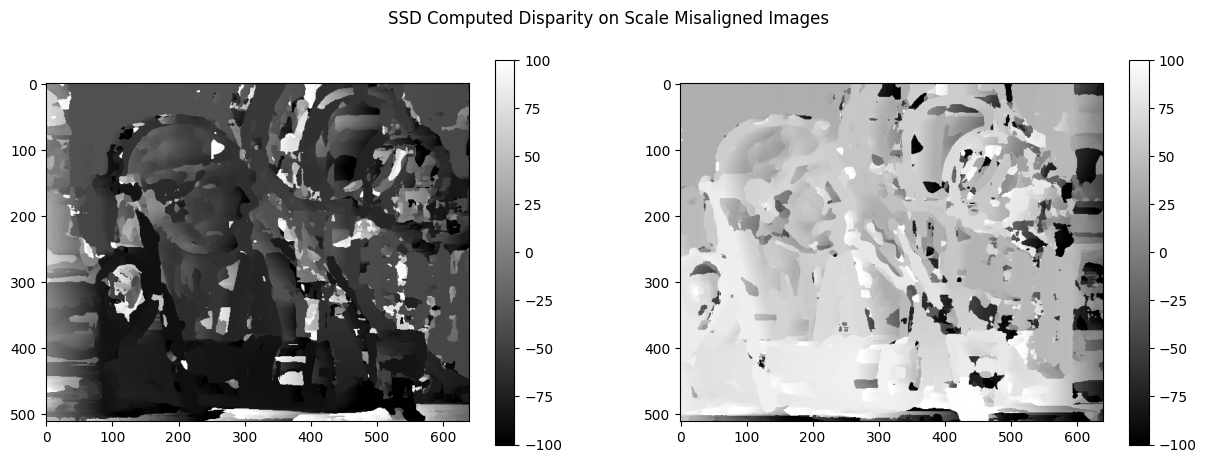

In [20]:
R_contrast = R * 1.1

D_L_cont = disparity_ssd_pixelwise_with_max_disparity(L, R_contrast, box_size=15)
D_R_cont = disparity_ssd_pixelwise_with_max_disparity(R_contrast, L, box_size=15)

plt.figure(figsize=(15, 5))
plt.suptitle('SSD Computed Disparity on Scale Misaligned Images')
plt.subplot(121)
plt.imshow(D_L_cont)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R_cont)
plt.colorbar()
plt.show()

imsave(D_L_blur, 'output/ps2-3-b-1.png')
imsave(D_R_blur, 'output/ps2-3-b-2.png')

What about now?

# Part 4 a

Implement a window matching stereo algorithm using some form of normalized correlation. Again, write this as a function disparity_ncorr(L, R) that returns a disparity image D(y,x) such that L(y,x) = R(y,x+D(y,x)) when matching from left (L) to right (R). 

Use OpenCV's funtion matchTemplate with flag TM_CCOEFF_NORMED. Take a look at some of the other flags they have available.

*Question*: What is the most efficient possible implementation of this new disparity function? Pixel-wise/column-wise/shared compuatation?

In [42]:
def disparity_ncorr(L, R, box_size):
    rows, cols = L.shape
    disparity_map = np.zeros_like(L, dtype=np.float32)
    L_pad = np.pad(L, box_size // 2, mode='edge').astype(np.float32)
    R_pad = np.pad(R, box_size // 2, mode='edge').astype(np.float32)
    for y in tqdm(range(rows), desc='Computing disparity map'):
        R_row = R_pad[y:y + box_size, :]
        for x in range(cols):
            L_patch = L_pad[y:y + box_size, x:x + box_size]
            ncorr = cv2.matchTemplate(R_row, L_patch, cv2.TM_CCORR_NORMED)
            best_match = cv2.minMaxLoc(ncorr)[3][0]
            disparity_map[y, x] = best_match - x
    return disparity_map  

In [44]:
D_L = disparity_ncorr(L, R, 15)
D_R = disparity_ncorr(R, L, 15)

Computing disparity map: 100%|██████████| 511/511 [00:30<00:00, 16.84it/s]


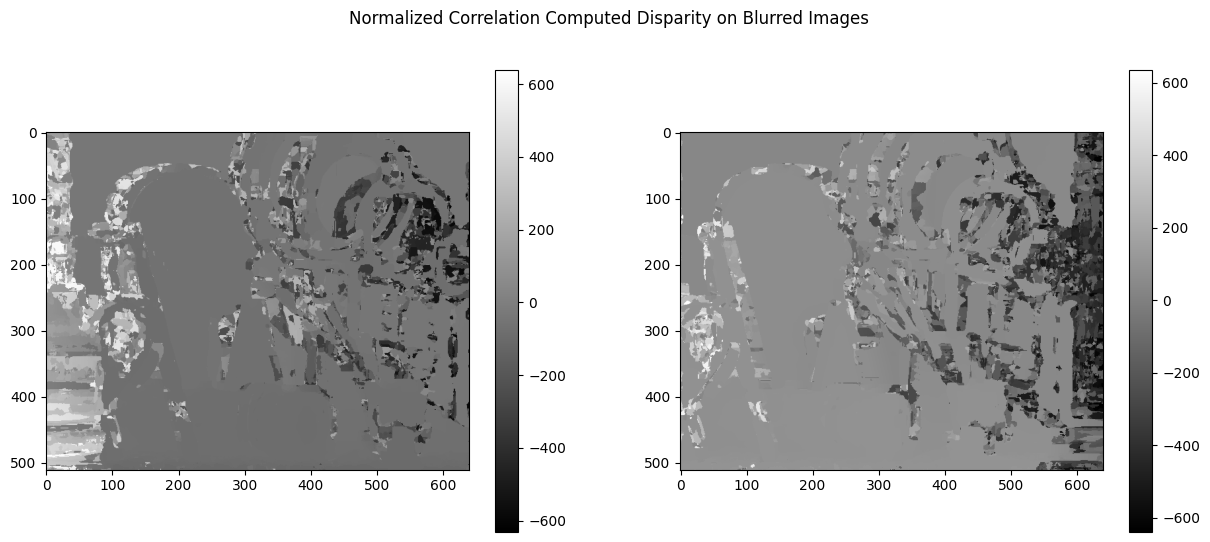

In [45]:
plt.figure(figsize=(15, 6))
plt.suptitle('Normalized Correlation Computed Disparity on Blurred Images')
plt.subplot(121)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R)
plt.colorbar()
plt.show()

imsave(D_L, 'output/ps2-4-a-1.png')
imsave(D_R, 'output/ps2-4-a-2.png')

How is the runtime? How do the results look?

# Part 4 b

### Now test it on both the noisy and contrast-boosted versions from 2-a and 2-b.

This new function should be more robust to pertubations, since it normalizes each patch by itself.

Let's try it on the blurred version:

Computing disparity map: 100%|██████████| 511/511 [00:37<00:00, 13.48it/s]


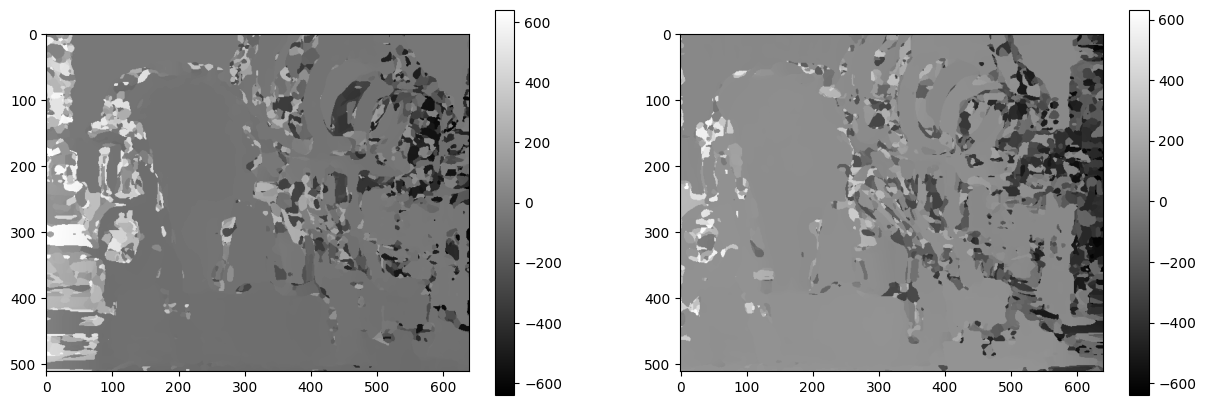

In [51]:
D_L_blur_ncorr = disparity_ncorr(L_blur, R_blur, 20)
D_R_blur_ncorr = disparity_ncorr(R_blur, L_blur, 20)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(D_L_blur_ncorr)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R_blur_ncorr)
plt.colorbar()
plt.show()

How does this look?

Now the contrast boosted version:

Computing disparity map: 100%|██████████| 511/511 [00:30<00:00, 16.86it/s]


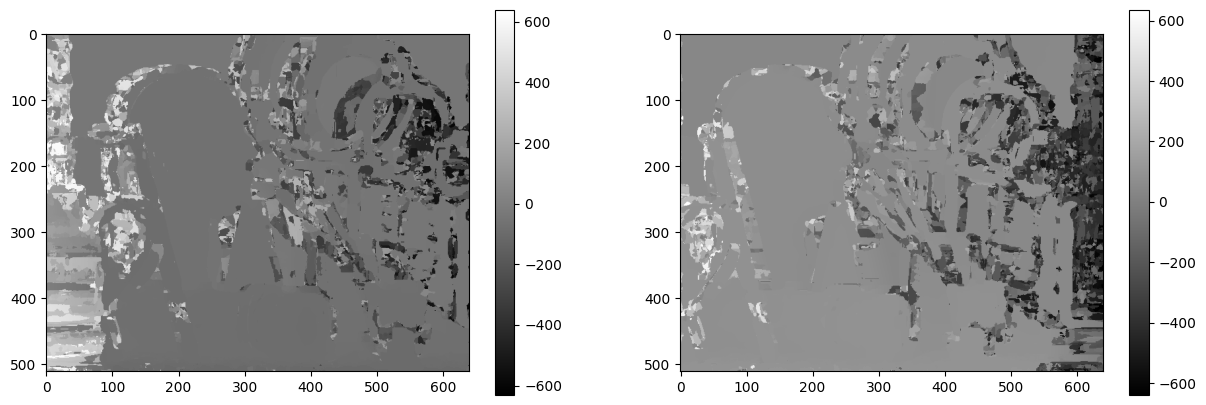

In [49]:
R_contrast = R * 1.1

D_L_cont_ncorr = disparity_ncorr(L, R_contrast, 15)
D_R_cont_ncorr = disparity_ncorr(R_contrast, L, 15)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(D_L_cont_ncorr)
plt.colorbar()
plt.subplot(122)
plt.imshow(D_R_cont_ncorr)
plt.colorbar()
plt.show()

What about this?

# Part 5 

Try your algorithms on this pair. Play with the images – smooth, sharpen, etc. Keep comparing to the ground truth (pair2-D_L.png and pair2-D_R.png).

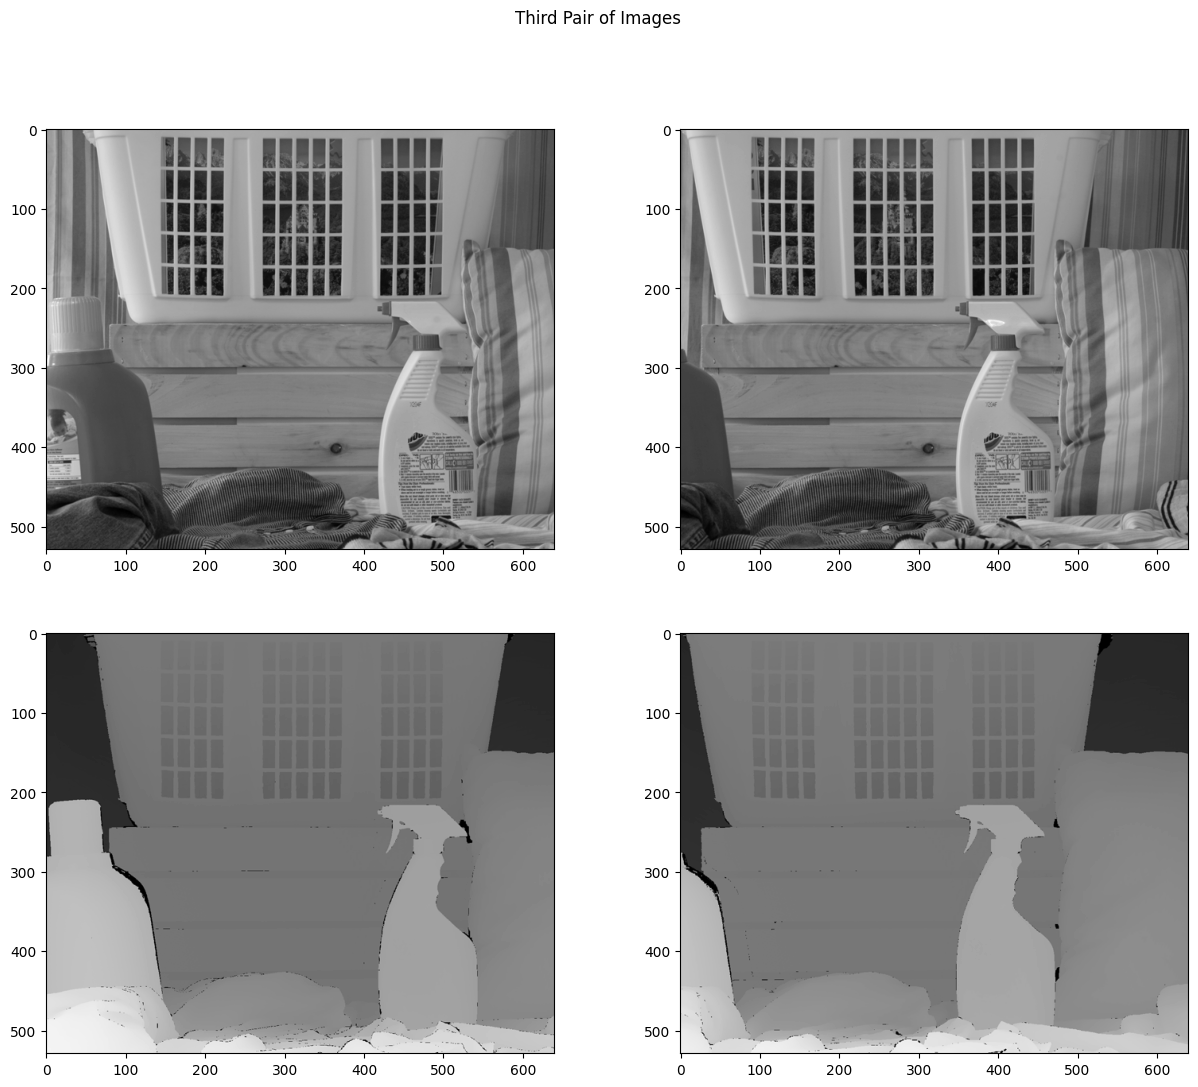

In [52]:
L = cv2.imread(os.path.join('input', 'pair2-L.png'), 0) / 255
R = cv2.imread(os.path.join('input', 'pair2-R.png'), 0) / 255
gt_D_L = cv2.imread(os.path.join('input', 'pair2-D_L.png'), 0)
gt_D_R = cv2.imread(os.path.join('input', 'pair2-D_R.png'), 0)

plt.figure(figsize=(15, 12))
plt.suptitle('Third Pair of Images')
plt.subplot(221)
plt.imshow(L)
plt.subplot(222)
plt.imshow(R)
plt.subplot(223)
plt.imshow(gt_D_L)
plt.subplot(224)
plt.imshow(gt_D_R)
plt.show()

Computing disparity map: 100%|██████████| 529/529 [00:31<00:00, 16.75it/s]


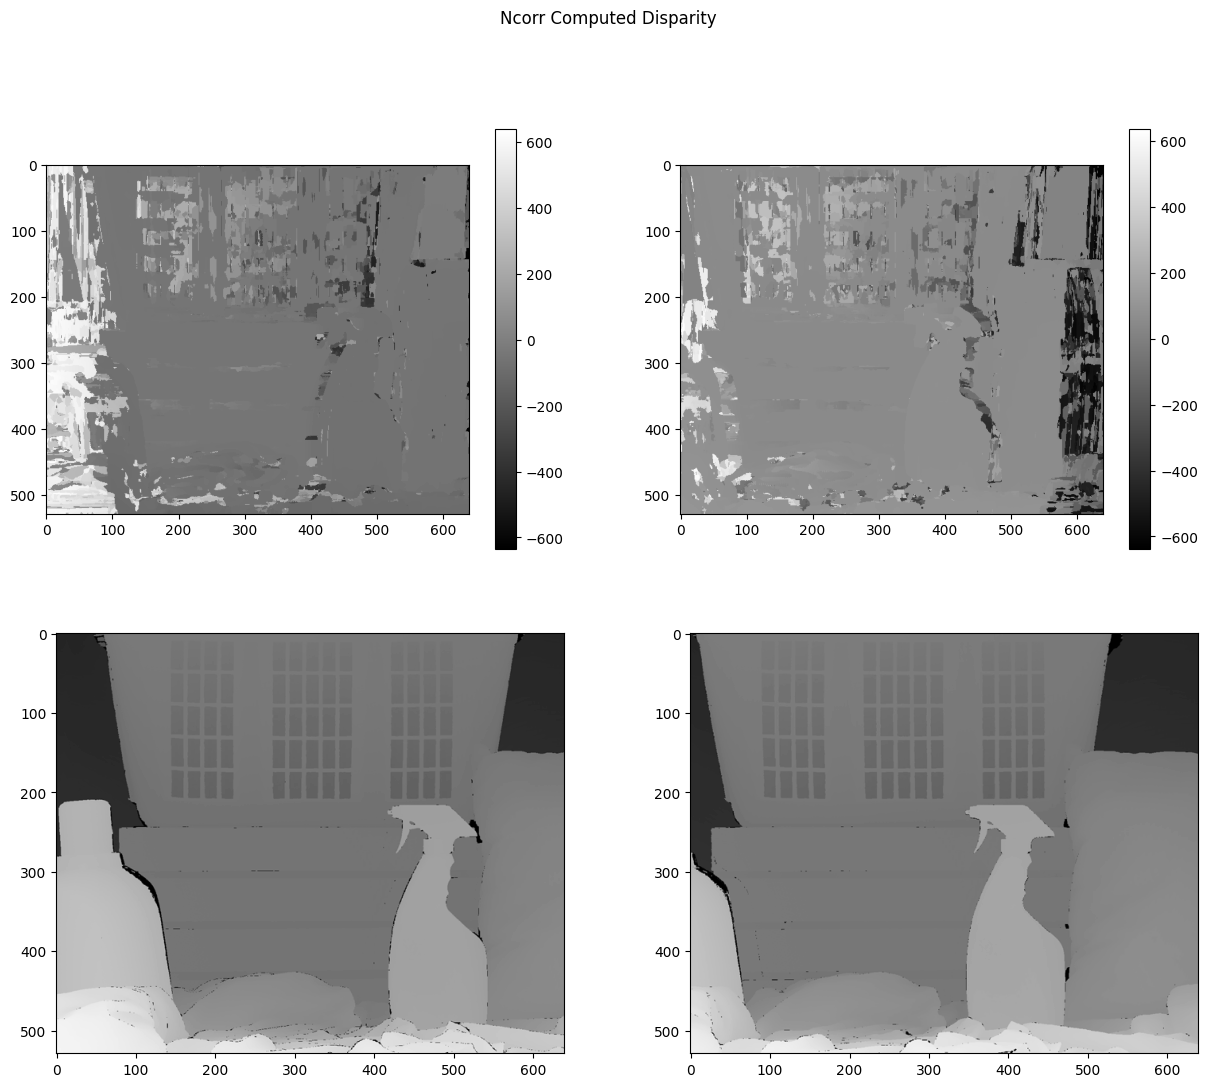

In [53]:
D_L = disparity_ncorr(L, R, 15)
D_R = disparity_ncorr(R, L, 15)

plt.figure(figsize=(15, 12))
plt.suptitle('Ncorr Computed Disparity')
plt.subplot(221)
plt.imshow(D_L)
plt.colorbar()
plt.subplot(222)
plt.imshow(D_R)
plt.colorbar()
plt.subplot(223)
plt.imshow(gt_D_L)
plt.subplot(224)
plt.imshow(gt_D_R)
plt.show()

How does this look? What hyperparmeter issues did you face?

*Question:* Can you automate this process? If so, how?